In [40]:
import numpy as np
import pandas as ps
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [41]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [42]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
#lets you build a neural n/w layer by layer in a linear fashion


from tensorflow.keras.layers import Dense
#fully connected layer (every neuron connects to every neuron in the next layer)

from tensorflow.keras.layers import Dropout
# randomly drop some neuron during training to prevent overfitting

from tensorflow.keras.utils import to_categorical
#convert class label (like 0,1,2) into one-hot-encoded format (e.g.[1,0,0],[0,1,0])




In [43]:
df=sns.load_dataset('iris')

In [44]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [45]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB


In [47]:
X=df.drop(columns=['species'])
y=df['species']

In [48]:
encoder=LabelEncoder()
y=encoder.fit_transform(y)

In [49]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [50]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [51]:
X_train.shape

(120, 4)

In [52]:
scale=StandardScaler()

X_train_scale=scale.fit_transform(X_train)
X_test_scale=scale.transform(X_test)

In [53]:
X_train_scale.shape

(120, 4)

In [54]:
per=Perceptron(max_iter=100,random_state=42)
per.fit(X_train_scale,y_train)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",100
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",42


In [55]:
y_pred=per.predict(X_test)

In [56]:
accuracy_score(y_pred,y_test)

0.7

In [57]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.00      0.00      0.00         0
           2       1.00      0.55      0.71        20

    accuracy                           0.70        30
   macro avg       0.67      0.52      0.57        30
weighted avg       1.00      0.70      0.81        30



In [58]:
y_train_cat=to_categorical(y_train,num_classes=3)
y_test_cat=to_categorical(y_test,num_classes=3)

In [59]:
y_train_cat

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1

In [60]:
model=Sequential([
    
    Dense(16,input_dim=4,activation='relu'),
    Dense(8,activation='relu'),
    Dense(3,activation='softmax')
])

In [61]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [62]:
history=model.fit(X_train_scale,y_train_cat,epochs=100,batch_size=8,validation_split=0.2,verbose=1)

Epoch 1/100


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.2708 - loss: 1.1306 - val_accuracy: 0.6250 - val_loss: 1.0582
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5000 - loss: 1.0609 - val_accuracy: 0.7083 - val_loss: 1.0135
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6354 - loss: 1.0077 - val_accuracy: 0.7083 - val_loss: 0.9742
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6771 - loss: 0.9627 - val_accuracy: 0.7500 - val_loss: 0.9412
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7083 - loss: 0.9243 - val_accuracy: 0.7500 - val_loss: 0.9093
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6979 - loss: 0.8904 - val_accuracy: 0.7500 - val_loss: 0.8790
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7083 - loss: 0.8588 - val_accuracy: 0.7500 - val_loss: 0.8493
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7396 - loss: 0.8278 - val_accuracy: 0.7500 - val_l

In [63]:
loss,acc=model.evaluate(X_test_scale,y_test_cat,verbose=1)
print(acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.9667 - loss: 0.0878
0.9666666388511658


In [64]:

print(acc)

0.9666666388511658


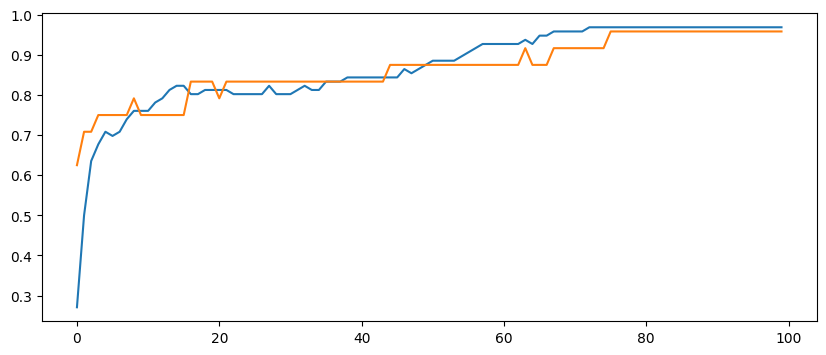

In [65]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'],label='"Train ACC')
plt.plot(history.history['val_accuracy'],label='"Train ACC')


In [80]:
model.save("iris_ann_model.keras")